# Basic I4C NetCDF data exploration

This notebook performs a basic exploration of NetCDF file contents, plots a map and a time series at a location and saves the output as a CSV.

In [1]:
import glob
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
#files = glob.glob('../I4C_CPRCM_CITY_DATA/ALPX-3i-Prague/tasmin_*.nc')
files = glob.glob('../I4C_EMULATOR_CITY_DATA/ALPX-3i-Prague/tasmin_*_MPI-ESM1-2-HR_*[a7]?_r1i1p1f1_*.nc') # historic(a)l and ssp3(7)0
ds = xr.open_mfdataset(files, combine='by_coords')
#ds = ds.sel(time=ds['time.season'] == 'JJA')
ds

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 55152, bnds: 2, lat: 59, lon: 91)
Coordinates:
  * time       (time) datetime64[ns] 441kB 1950-01-01T12:00:00 ... 2100-12-31...
  * lat        (lat) float64 472B 49.17 49.2 49.23 49.27 ... 50.92 50.95 50.98
  * lon        (lon) float64 728B 13.11 13.14 13.17 13.2 ... 15.86 15.89 15.92
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 882kB dask.array<chunksize=(23741, 2), meta=np.ndarray>
    tasmin     (time, lat, lon) float32 1GB dask.array<chunksize=(195, 59, 91), meta=np.ndarray>
Attributes: (12/36)
    CDI:                         Climate Data Interface version 2.5.0 (https:...
    Conventions:                 CF-1.11
    source:                      DeepESD1 emulator (t18) trained on WRF451R-C...
    institution:                 UCAN [Instituto de Fisica de Cantabria (IFCA...
    activity_id:                 emulation
    contact:                     meteo@unican.es
    ...                          ...
    license:                     https://impetus4change.github.io/WP3/i4c-emu...
    reference:                   Baño-Medina et al. (2024) Transferability an...
    tracking_id:                 hdl:21.14103/2a18ea41-6541-4e9d-ab80-fd843b6...
    creation_date:               2026-02-20T13:33:52Z
    history:                     Tue Jun 23 13:39:51 2026: cdo mergetime I4C_...
    CDO:                         Climate Data Operators version 2.5.0 (https:...

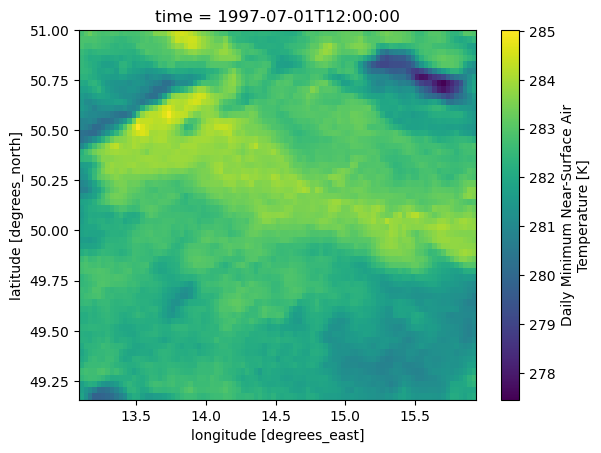

In [3]:
hm = ds.tasmin.sel(time='1997-07-01').plot()

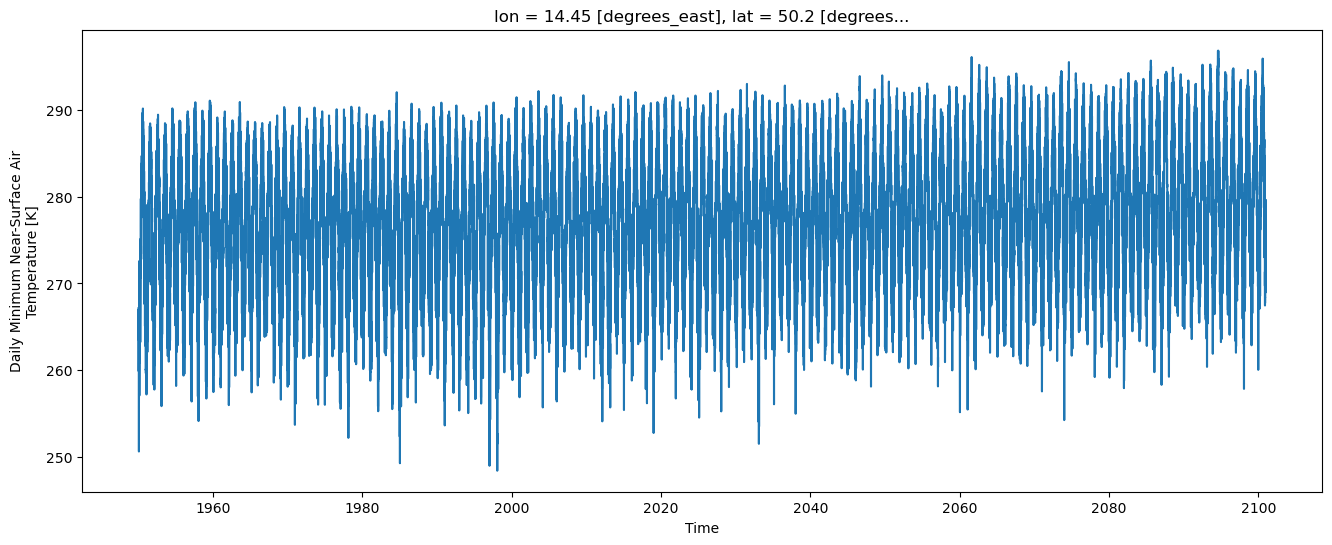

In [4]:
# E.g. location of Prague
target_lat = 50.2 # 50.0755
target_lon = 14.4378

time_series = ds.tasmin.sel(lat=target_lat, lon=target_lon, method='nearest')

fig, ax = plt.subplots(figsize=(16, 6))
ht = time_series.plot(ax=ax)

In [5]:
# CSV export with header: date,tasmin
df = time_series.to_dataframe()[['tasmin']]
df.to_csv('prague_tasmin_timeseries.csv', index=True, header=True)
df

,tasmin
time,
1950-01-01 12:00:00,267.134552
1950-01-02 12:00:00,266.271179
1950-01-03 12:00:00,265.237793
1950-01-04 12:00:00,265.204712
1950-01-05 12:00:00,265.746826
...,...
2100-12-27 12:00:00,276.140503
2100-12-28 12:00:00,274.165680
2100-12-29 12:00:00,276.776794


Let's try to unveil the city by removing day-to-day variability and retaining only differences with respect to a grid point in the city center.

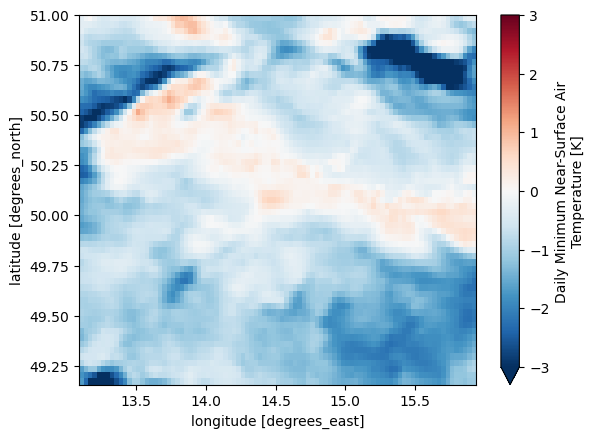

In [6]:
tasmin_diff = ds.tasmin - time_series   
tasmin_diff_mean = tasmin_diff.mean(dim='time')
ax = tasmin_diff_mean.plot(cmap='RdBu_r', vmin=-3, vmax=3)

This pattern is related to the orography, but also to the presence of the city

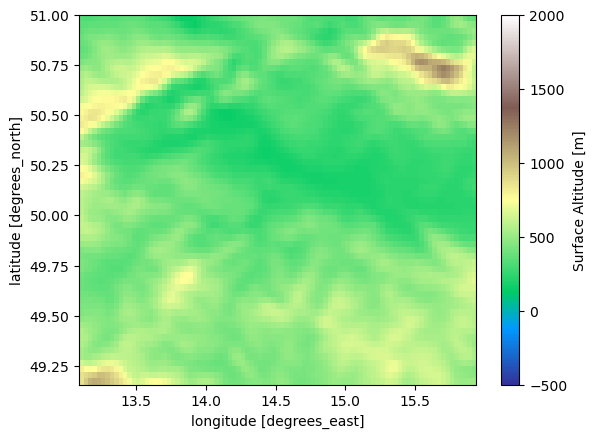

In [7]:
dso = xr.open_dataset(glob.glob('../I4C_CPRCM_CITY_DATA/ALPX-3i-Prague/orog_*.nc')[0])
ax = dso.orog.plot(cmap='terrain', vmin=-500, vmax=2000)

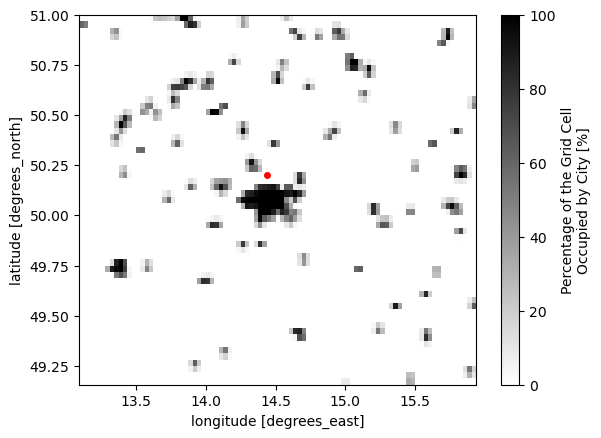

In [8]:
dsu = xr.open_dataset(glob.glob('../I4C_CPRCM_CITY_DATA/ALPX-3i-Prague/sfturf_*.nc')[0])
ax = dsu.sfturf.plot(cmap='gray_r')
plt.plot(target_lon, target_lat, 'ro', markersize=4)  # mark the location selected above